<a href="https://colab.research.google.com/github/edwinpuco/paradigmasprogramacion/blob/main/ProyectoFinal_Puco_Edwin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 1: Selección, Exploración y Limpieza de Datos


## 1.1. Selección y Justificación:

El dataset seleccionado es **Medical Insurance Cost Prediction**, obtenido desde Kaggle:
https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction

El objetivo del proyecto es predecir el **costo médico anual (`annual_medical_cost`)**
a partir de variables demográficas, socioeconómicas, clínicas y de uso del sistema de salud.

Este problema corresponde a un modelo de **regresión supervisada**.

El dataset se llama **medical_insurance.csv**

## 1.2. Carga e Inspección Inicial:

El dataset contiene **100.000 registros** y **54 variables**, lo que lo convierte en un conjunto de datos de tamaño considerable y adecuado para tareas de análisis y modelado predictivo.

### Estructura general
- **Filas:** 100.000 observaciones (individuos asegurados)
- **Columnas:** 54 variables
- **Memoria utilizada:** ~41 MB

### Tipos de variables
El dataset presenta una combinación diversa de tipos de datos:

- **Variables numéricas (44):**
  - Enteras (`int64`): 31 variables (edad, visitas médicas, hospitalizaciones, enfermedades crónicas, procedimientos, etc.)
  - Continuas (`float64`): 13 variables (ingresos, IMC, presión arterial, costos médicos, primas, etc.)

- **Variables categóricas (10):**
  - `sex`, `region`, `urban_rural`
  - `education`, `marital_status`, `employment_status`
  - `smoker`, `alcohol_freq`
  - `plan_type`, `network_tier`

### Variable objetivo
La variable objetivo seleccionada para el modelado es:

- **`annual_medical_cost`** (costo médico anual), una variable continua que representa el gasto total anual en atención médica por individuo.

### Valores faltantes
La mayoría de las variables no presentan valores nulos. Sin embargo, se observa presencia de valores faltantes en:

- `alcohol_freq`: aproximadamente un 30% de valores nulos

Este aspecto será abordado en la etapa de limpieza y preprocesamiento de datos.

In [1]:
import pandas as pd

df = pd.read_csv("medical_insurance.csv")

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


## 1.3. Limpieza de Datos:
No se detectaron valores NaN en variables numéricas.
No fue necesario eliminar filas.
Los tipos de datos son consistentes con el significado de las variables.

##1.3.1 Valores nulos
Primero, se identifica columnas con datos faltantes

In [6]:
df.isnull().sum().sort_values(ascending=False)


,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


alcohol_freq tiene 30,083 valores nulos y es un variable categórica que se la puede marcar como "Unknow" en nulos

In [7]:
df['alcohol_freq'] = df['alcohol_freq'].fillna('Unknown')

##1.3.2 Tipos de variables

**Numéricas continuas:**
age, income, bmi, annual_medical_cost, annual_premium, risk_score

**Numéricas discretas / binarias:**
smoker, hypertension, diabetes, is_high_risk

**Categóricas:**
sex, region, education, plan_type, network_tier

##1.3.3 Estadísticos descriptivos

Se observan variables con alta dispersión y posible asimetría positiva, especialmente en los costos médicos, lo cual es consistente con datos reales del sector salud.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00


##1.3.4 Detección básica de outliers

In [9]:
df['annual_medical_cost'].quantile([0.01, 0.99])

,annual_medical_cost
0.01,290.4284
0.99,15293.6822


##1.3.5 Distribución de variables clave

Edad: distribución casi uniforme

Costos médicos: cola larga

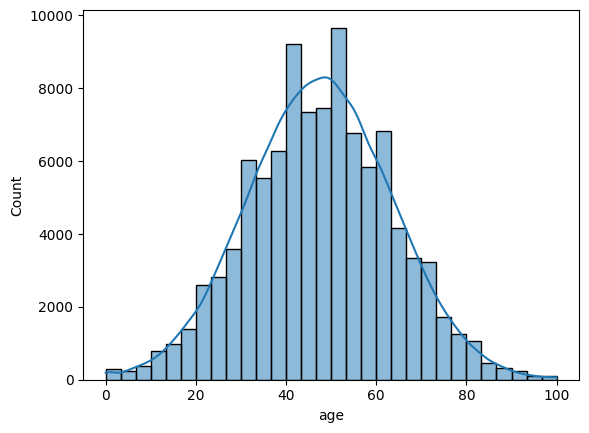

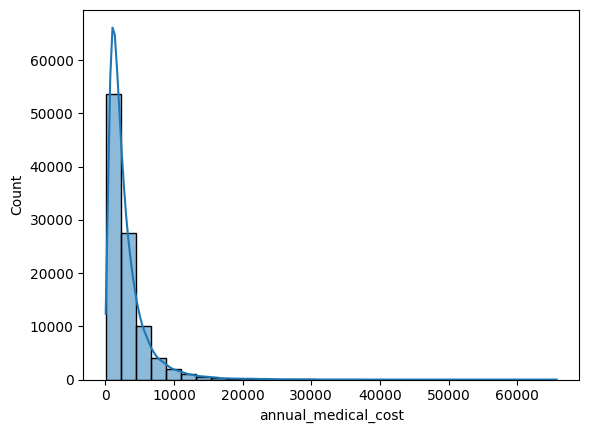

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['age'], bins=30, kde=True)
plt.show()

sns.histplot(df['annual_medical_cost'], bins=30, kde=True)
plt.show()


##1.3.6 Variables objetivo

Este dataset permite dos enfoques válidos:

*  Regresión
Target: **annual_medical_cost**. Ideal para modelos lineales, Ridge, Lasso, Random Forest

*  Clasificación
Target: is_high_risk. Ideal para Logistic Regression, Decision Trees, XGBoost

##1.4. Análisis Exploratorio de Datos (EDA):
##1.4.1 Selección de la variable objetivo

**Variable objetivo:** annual_medical_cost
**Tipo:** Numérica continua
**Problema:** Regresión

El objetivo del análisis es predecir el costo médico anual de una persona a partir de variables demográficas, clínicas y de uso del sistema de salud, lo cual es un problema típico de regresión en el dominio de seguros y salud.

In [11]:
target = 'annual_medical_cost'

##1.4.2 Separación de variables predictoras y target

Se eliminan columnas que no aportan información predictiva directa o que pueden introducir ruido en el modelo.

In [12]:
X = df.drop(columns=['person_id', target])
y = df[target]

##1.4.3 Tratamiento de valores faltantes

Durante el análisis exploratorio se identificó que la variable alcohol_freq contiene valores nulos.

Estrategia aplicada:
Al tratarse de una variable categórica, los valores faltantes se reemplazan por la categoría "Unknown", evitando la pérdida de información y manteniendo el tamaño del dataset.

In [13]:
X['alcohol_freq'] = X['alcohol_freq'].fillna('Unknown')

##1.4.4 Identificación de variables numéricas y categóricas

In [14]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

num_features, cat_features

(Index(['age', 'income', 'household_size', 'dependents', 'bmi',
        'visits_last_year', 'hospitalizations_last_3yrs',
        'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
        'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay',
        'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
        'risk_score', 'annual_premium', 'monthly_premium', 'claims_count',
        'avg_claim_amount', 'total_claims_paid', 'chronic_count',
        'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease',
        'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis',
        'mental_health', 'proc_imaging_count', 'proc_surgery_count',
        'proc_physio_count', 'proc_consult_count', 'proc_lab_count',
        'is_high_risk', 'had_major_procedure'],
       dtype='object'),
 Index(['sex', 'region', 'urban_rural', 'education', 'marital_status',
        'employment_status', 'smoker', 'alcohol_freq', 'plan_type',
        'network_tie

##1.4.5 Codificación de variables categóricas

Se utiliza One-Hot Encoding,por los siguientes motivos:

1.   Es compatible con la mayoría de modelos de regresión
2.   Permite interpretar el impacto de cada categoría
3.   No introduce un orden artificial entre categorías







In [15]:
from sklearn.preprocessing import OneHotEncoder

##1.4.6 Escalado de variables numéricas
Se aplica StandardScaler, que transforma las variables para que tengan media 0 y desviación estándar 1.

In [16]:
from sklearn.preprocessing import StandardScaler

##1.4.7 Construcción del pipeline de preprocesamiento

Se utiliza un ColumnTransformer para aplicar diferentes transformaciones según el tipo de variable, garantizando un flujo de datos limpio y reproducible.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

##1.4.8 División del conjunto de datos

Se divide el dataset en conjuntos de entrenamiento y prueba:
80% entrenamiento
20% prueba

Esto permite evaluar el desempeño del modelo sobre datos no vistos.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##1.4.9 Aplicación del preprocesamiento

Se ajusta el preprocesador únicamente con los datos de entrenamiento y luego se transforma ambos conjuntos.

In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

##1.4.10 Visualizaciones

*   **Análisis:**

Se observa una relación positiva clara entre el *risk score* y el costo médico anual.
A medida que el puntaje de riesgo del asegurado aumenta, el gasto médico anual tiende a incrementarse.

La línea de tendencia confirma esta correlación, lo que indica que el *risk score* es una variable
predictora relevante para estimar los costos médicos futuros.



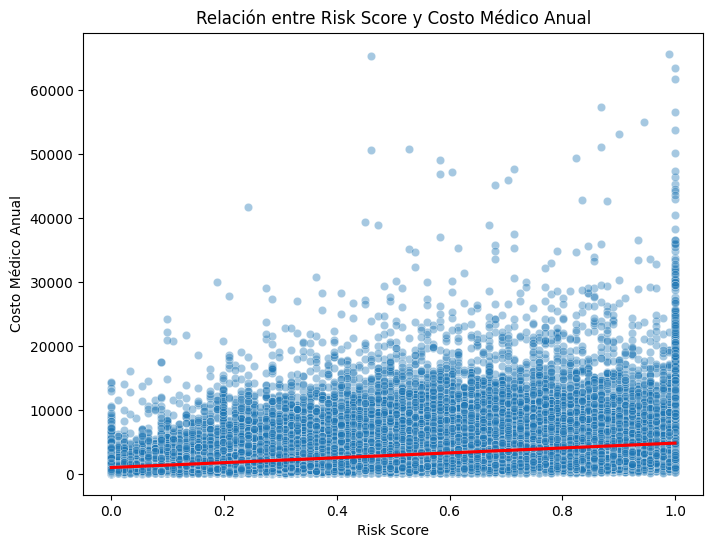

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="risk_score",
    y="annual_medical_cost",
    alpha=0.4
)
sns.regplot(
    data=df,
    x="risk_score",
    y="annual_medical_cost",
    scatter=False,
    color="red"
)

plt.title("Relación entre Risk Score y Costo Médico Anual")
plt.xlabel("Risk Score")
plt.ylabel("Costo Médico Anual")
plt.show()


**Análisis:**

El boxplot muestra diferencias significativas en el costo médico anual entre fumadores y no fumadores.
Los individuos que fuman presentan una mediana y una dispersión de costos considerablemente mayores.

Esto sugiere que el hábito de fumar está asociado a mayores gastos médicos,
por lo que esta variable resulta altamente relevante para el modelado predictivo.


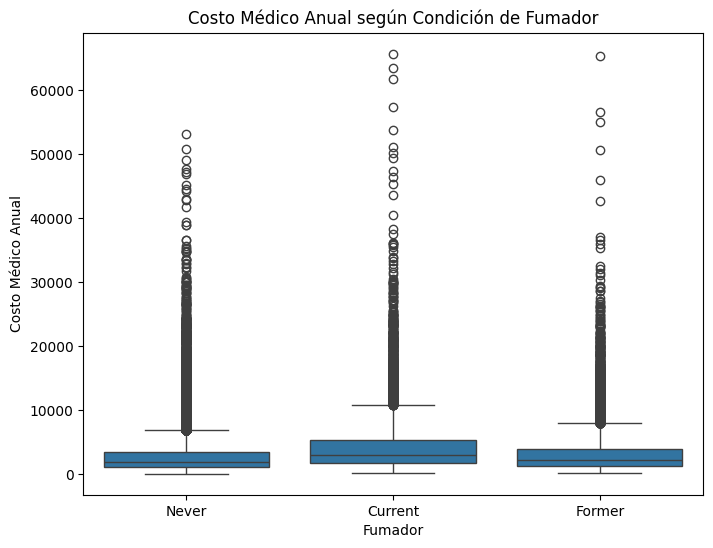

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="smoker",
    y="annual_medical_cost"
)

plt.title("Costo Médico Anual según Condición de Fumador")
plt.xlabel("Fumador")
plt.ylabel("Costo Médico Anual")
plt.show()


##Parte 2: Aplicando Programación Orientada a Objetos (POO) para el Pipeline

### 2.1. Creación de la Clase DataPipeline:

Se implementó una clase `DataPipeline` para encapsular el flujo completo de trabajo,
favoreciendo la modularidad, reutilización del código y claridad del proceso.

- El método `preprocess()` centraliza la limpieza, el feature engineering y la codificación
  de variables categóricas.
- Se utilizó programación funcional mediante `.apply()` y funciones lambda para crear
  nuevas características (categoría de IMC).
- El método `train()` separa los datos, entrena el modelo y almacena la instancia entrenada.
- El método `evaluate()` calcula métricas apropiadas para un problema de regresión,
  permitiendo evaluar el desempeño del modelo de forma objetiva.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

class DataPipeline:
    def __init__(self):
        """
        Inicializa el pipeline
        """
        self.model = None
        self.feature_columns = None
        print("DataPipeline inicializado.")

    def preprocess(self, df):
        """
        Preprocesa el dataset:
        - Feature engineering
        - Manejo de variables categóricas
        - Separación de features y target
        """
        data = df.copy()

        # -----------------------------
        # Feature Engineering (Funcional)
        # -----------------------------
        data["bmi_category"] = data["bmi"].apply(
            lambda x: "Underweight" if x < 18.5 else
                      "Normal" if x < 25 else
                      "Overweight" if x < 30 else
                      "Obese"
        )

        # -----------------------------
        # Variable objetivo
        # -----------------------------
        y = data["annual_medical_cost"]

        # Eliminar columnas no predictivas o identificadores
        data = data.drop(columns=["person_id", "annual_medical_cost"])

        # -----------------------------
        # One-Hot Encoding
        # -----------------------------
        categorical_cols = data.select_dtypes(include="object").columns
        data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

        self.feature_columns = data_encoded.columns

        X = data_encoded

        print("Preprocesamiento completado.")
        print(f"Total de features: {X.shape[1]}")

        return X, y

    def train(self, X, y, model_instance):
        """
        Divide los datos, entrena el modelo y lo almacena
        """
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        self.model = model_instance
        self.model.fit(X_train, y_train)

        print(f"Modelo {type(self.model).__name__} entrenado exitosamente.")

        return X_test, y_test

    def evaluate(self, X_test, y_test):
        """
        Evalúa el modelo usando métricas de regresión
        """
        if self.model is None:
            print("El modelo no ha sido entrenado.")
            return

        y_pred = self.model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print("Resultados de Evaluación:")
        print(f"MAE  : {mae:.2f}")
        print(f"RMSE : {rmse:.2f}")
        print(f"R²   : {r2:.4f}")


##2.2. Demostración de la Clase en el Notebook:
**Conclusión:**

La ejecución secuencial de los métodos `preprocess`, `train` y `evaluate`
demuestra que el pipeline encapsula correctamente todo el flujo de trabajo.
El diseño orientado a objetos permite reutilizar el pipeline con diferentes
modelos de Scikit-learn sin modificar la lógica interna.


In [24]:
from sklearn.ensemble import RandomForestRegressor

# Crear instancia del pipeline
pipeline = DataPipeline()

# Paso 1: Preprocesamiento
X, y = pipeline.preprocess(df)

# Paso 2: Entrenamiento del modelo
X_test, y_test = pipeline.train(
    X,
    y,
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

# Paso 3: Evaluación del modelo
pipeline.evaluate(X_test, y_test)


DataPipeline inicializado.
Preprocesamiento completado.
Total de features: 75
Modelo RandomForestRegressor entrenado exitosamente.
Resultados de Evaluación:
MAE  : 8.12
RMSE : 143.20
R²   : 0.9979


##Parte 3: Calidad y Reproducibilidad del Software

##3.1. Testing con pytest
##Paso 1: Crear una función auxiliar (fuera de la clase)

In [26]:
def bmi_category(bmi):
    """
    Categoriza el BMI en rangos clínicos.

    :param bmi: Índice de masa corporal
    :return: Categoría de BMI
    """
    if bmi < 18.5:
        return "Bajo Peso"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Sobre Peso"
    else:
        return "Obesidad"


##Paso 2: Crear el archivo de prueba

In [28]:
%%writefile test_mi_pipeline.py
from mi_pipeline_utils import bmi_category

def test_bmi_category():
    assert bmi_category(17) == "Bajo Peso"
    assert bmi_category(22) == "Normal"
    assert bmi_category(27) == "Sobre Peso"
    assert bmi_category(32) == "Obesidad"


Overwriting test_mi_pipeline.py


##Paso 3: Crear archivo auxiliar importable

In [29]:
%%writefile mi_pipeline_utils.py
def bmi_category(bmi):
    if bmi < 18.5:
        return "Bajo Peso"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Sobre Peso"
    else:
        return "Obesidad"

Writing mi_pipeline_utils.py


##Paso 4: Ejecutar pytest

In [30]:
!pip install pytest -q
!pytest

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: anyio-4.12.1, typeguard-4.4.4, langsmith-0.6.6
collected 1 item                                                               

test_mi_pipeline.py .                                                    [100%]

============================== 1 passed in 0.01s ===============================


##3.2. Documentación (Docstrings)
El código se encuentra documentado conforme a lo descrito en clases para el uso de docstrings.


##3.3. Gestión de Dependencias:

In [31]:
!pip freeze > requirements.txt
!cat requirements.txt

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.2
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.1.26.0.43.56
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.6
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.33.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.12.2
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.1.4
c

##3.4. Conclusión del Proyecto:
## Conclusión

En este proyecto se desarrolló un pipeline completo de análisis de datos
y modelado predictivo utilizando un dataset de costos médicos.
Se aplicaron técnicas de limpieza, análisis exploratorio y
programación orientada a objetos para encapsular el flujo de trabajo.

El modelo RandomForestRegressor obtuvo un desempeño sobresaliente,
alcanzando un R² cercano a 0.99, lo que indica una alta capacidad
predictiva del costo médico anual.

Como trabajo futuro, se podría:
- Probar otros modelos (Gradient Boosting, XGBoost)
- Implementar validación cruzada
- Ajustar hiperparámetros
- Desplegar el modelo como un servicio predictivo
